# Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"
import warnings
warnings.filterwarnings('ignore')
from scipy import optimize, interpolate
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error
import copy
import tensorflow as tf
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from sklearn.linear_model import LinearRegression
import random

# Gather Data

In [2]:
Data_dir = "Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))

## Plot the Data

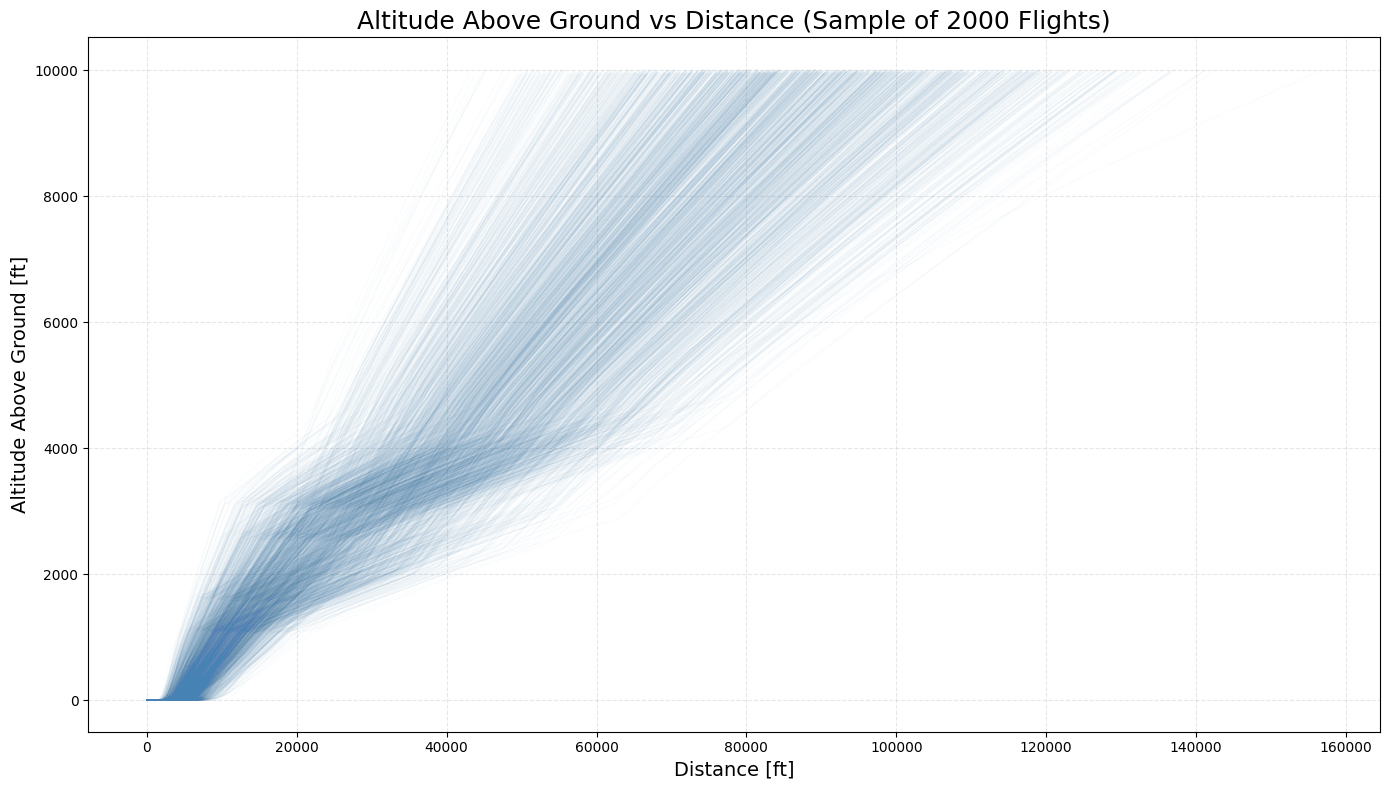

In [186]:
plt.figure(figsize=(14, 8))

for f in f_lst[:2000]:
    df = pd.read_csv(f)
    plt.plot(
        df["Distance"],
        df["Altitude_Above_Ground"],
        color="steelblue",
        linewidth=0.8,
        alpha=0.03
    )

plt.title("Altitude Above Ground vs Distance (Sample of 2000 Flights)", fontsize=18)
plt.xlabel("Distance [ft]", fontsize=14)
plt.ylabel("Altitude Above Ground [ft]", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Save the figure (high resolution)
plt.savefig("altitude_distance_plot.png", dpi=300)

plt.show()

## Weight Model Data

In [5]:
desired_columns = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2", "Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3", "acc_max", "Total_Weight"]

In [85]:
weight_min = 110000
weight_max = 174000
cutoff_weight_top = 3/4
cutoff_weight_bot = 1/4
throttle_top_max = 1.0
throttle_bot_max = 0.98
throttle_top_min = 0.935
throttle_bot_min = 0.89
counter = 0
null_counter = 0
i = 0
Data_Weight = pd.DataFrame(columns = desired_columns + ["ID"])
f_lst_bad = []
weight_lst = []
throttle_lst = []
for f in f_lst[:]:
    if np.mod(counter, 100)==0:
        print("counter = ", counter)
    counter+=1
    df = pd.read_csv(f)

    # Get the good slice of data for weight model
    t0 = df[df["Segment"]=="Take_Off"].iloc[-1]["Throttle"]
    weight_0 = df.iloc[0]["Total_Weight"]
    weight_ratio = (weight_0-weight_min)/(weight_max-weight_min)
    if weight_ratio>cutoff_weight_top:
        throttle_top = copy.copy(throttle_top_max)
    else:
        throttle_top = throttle_top_min + (throttle_top_max-throttle_top_min)/cutoff_weight_top*weight_ratio
    
    if weight_ratio<cutoff_weight_bot:
        throttle_bot = copy.copy(throttle_bot_min)
    else:
        throttle_bot = throttle_bot_min + (throttle_bot_max-throttle_bot_min)/(1-cutoff_weight_bot)*(weight_ratio-cutoff_weight_bot)

    if (t0<throttle_bot) or (t0>throttle_top):
        null_counter += 1
        f_lst_bad.append(f)
        continue
    data_temp = df[(df["Throttle"]==t0)&(df["Segment"]=="Slow_Climb")]
    tolerance = 3
    stability_window = 5
    stability_threshold = 3
    data_temp["near_command"] = (data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).mean().sub(df.iloc[0]["Climb_CAS"]).abs() < tolerance)
    data_temp["cas_std"] = data_temp["CAS"].rolling(stability_window, center=True, min_periods=1).std()
    data_temp["stable"] = data_temp["cas_std"] < stability_threshold
    data_temp["good"] = data_temp["near_command"] & data_temp["stable"]
    data_temp["slice"] = (data_temp["good"] != data_temp["good"].shift()).cumsum()
    slices = data_temp[data_temp["good"]].groupby("slice")
    if np.sum(data_temp["good"])==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    longest_slice_id = slices.size().idxmax()
    longest_slice = data_temp[data_temp["slice"] == longest_slice_id].copy()
    if len(longest_slice)==0:
        null_counter+=1
        f_lst_bad.append(f)
        continue
    else:
        weight_lst.append(weight_0)
        throttle_lst.append(t0)
        Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = longest_slice[["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        # Data_Weight.loc[i, ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1"]] = df[(df["Altitude_Above_Ground"]>600) & (df["Altitude_Above_Ground"]<800)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["Vg_3", "Vc_3", "wind_speed_3", "wind_dir_cos_3", "wind_dir_sin_3", "theta_3", "sigma_3", "delta_3", "roll_3", "climb_angle_3"]] = df[(df["Altitude_Above_Ground"]>9000) & (df["Altitude_Above_Ground"]<10100)][["Ground_Speed", "CAS", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, ["acc", "wind_speed_2", "wind_dir_cos_2", "wind_dir_sin_2", "theta_2", "sigma_2", "delta_2", "roll_2", "climb_angle_2"]] = df[df["Segment"]=="Acceleration"].iloc[-10:][["Acceleration", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "theta", "sigma", "delta", "Roll", "vpath"]].mean().values
        Data_Weight.loc[i, "Total_Weight"] = df["Total_Weight"].mean()
        Data_Weight.loc[i, "Climb_CAS"] = df.loc[0, "Climb_CAS"]
        Data_Weight.loc[i, "ID"] = f
        Data_Weight.loc[i, "Thrust_Max"] = np.max(df["Thrust"])
        df_acc = df[(df["Ground_Speed"]>5) & (df["Ground_Speed"]<15)]
        Data_Weight.loc[i, "acc_max"] = (df_acc.iloc[-1]["Ground_Speed"]-df_acc.iloc[0]["Ground_Speed"])/(df_acc.iloc[-1]["Time"]-df_acc.iloc[0]["Time"])
        i+=1

counter =  0
counter =  100
counter =  200
counter =  300
counter =  400
counter =  500
counter =  600
counter =  700
counter =  800
counter =  900
counter =  1000
counter =  1100
counter =  1200
counter =  1300
counter =  1400
counter =  1500
counter =  1600
counter =  1700
counter =  1800
counter =  1900
counter =  2000
counter =  2100
counter =  2200
counter =  2300
counter =  2400
counter =  2500
counter =  2600
counter =  2700
counter =  2800
counter =  2900
counter =  3000
counter =  3100
counter =  3200
counter =  3300
counter =  3400
counter =  3500
counter =  3600
counter =  3700
counter =  3800
counter =  3900
counter =  4000
counter =  4100
counter =  4200
counter =  4300
counter =  4400
counter =  4500
counter =  4600
counter =  4700
counter =  4800
counter =  4900
counter =  5000
counter =  5100
counter =  5200
counter =  5300
counter =  5400
counter =  5500
counter =  5600
counter =  5700
counter =  5800
counter =  5900
counter =  6000
counter =  6100
counter =  6200
coun

In [86]:
null_counter

5667

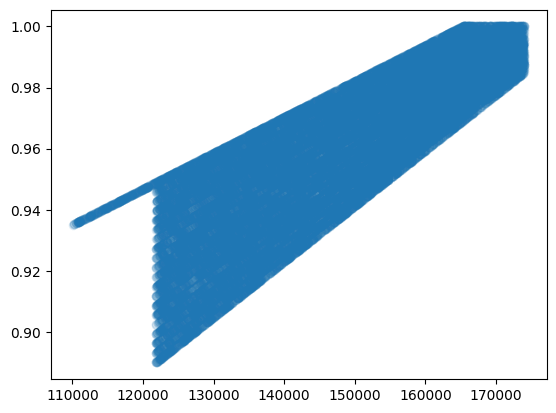

In [87]:
plt.scatter(weight_lst, throttle_lst, alpha=0.1)

In [88]:
Data_Weight = Data_Weight[Data_Weight["Total_Weight"]>123000]

In [89]:
n1 = 0.8
n2 = 0.9
Data_Weight.dropna(inplace=True)
train, val, test = np.split(Data_Weight.sample(frac=1, random_state=42), [int(n1*len(Data_Weight)), int(n2*len(Data_Weight))])

In [90]:
pd.concat([train, val]).to_csv("Data/Data_Train_Weight_Dep.csv", index=False)
test.to_csv("Data/Data_Test_Weight_Dep.csv", index=False)

In [91]:
Data_Weight.shape

(25071, 34)

# Read Training Data

In [2]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")

<Axes: >

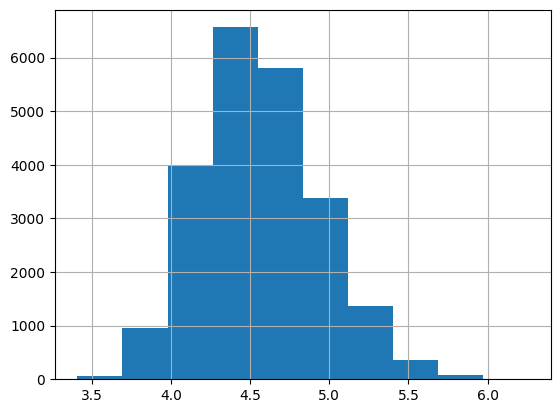

In [3]:
Data["acc_max"].hist()

In [6]:
Data[desired_columns].corr()["Total_Weight"].sort_values()

climb_angle_1    -0.436416
climb_angle_3    -0.333683
acc_max          -0.282473
acc              -0.281641
climb_angle_2    -0.143612
theta_3          -0.053723
theta_1          -0.051313
theta_2          -0.044318
wind_dir_sin_3   -0.015791
wind_dir_sin_2   -0.013538
wind_speed_2     -0.013037
wind_speed_1     -0.011277
wind_speed_3     -0.011241
wind_dir_cos_1   -0.004204
wind_dir_sin_1    0.001843
Vg_3              0.002141
roll_1            0.005721
roll_3            0.006137
wind_dir_cos_2    0.038825
wind_dir_cos_3    0.040323
roll_2            0.050500
delta_3           0.114192
delta_1           0.121849
delta_2           0.122423
sigma_3           0.129208
sigma_2           0.134870
sigma_1           0.134883
Vg_1              0.413328
Vc_3              0.929703
Vc_1              0.973646
Total_Weight      1.000000
Name: Total_Weight, dtype: float64

In [7]:
# all_names = desired_columns
all_names = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight"]
x_names = all_names[:-1]

In [8]:
# scaler = StandardScaler().fit(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values)
# Data_scaled = pd.DataFrame(scaler.transform(Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data.index, columns=Data[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [10]:
n1 = 0.8
n2 = 0.9
# X_train, X_val, y_train, y_val = train_test_split(Data_scaled[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3"]], Data_scaled[['Total_Weight']], test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Total_Weight']], test_size=(n2-n1)/n2)

# Create the Weight Model

In [11]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 465 (1.82 KB)

 Trainable params: 465 (1.82 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Weight Model

## 1st LR

In [13]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [14]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 889us/step - loss: 0.2145 - val_loss: 0.1634
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - loss: 0.1725 - val_loss: 0.1655
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.1679 - val_loss: 0.1738
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - loss: 0.1670 - val_loss: 0.1617
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.1675 - val_loss: 0.1785
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step - loss: 0.1680 - val_loss: 0.1628
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - loss: 0.1658 - val_loss: 0.1589
Epoch 8/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - loss: 0.1660 - val_loss: 0.1754
Epoch 9/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 0.1648 - val_loss: 0.1621
Epoch 10/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - loss: 0.1653 - val_loss: 0.1632


In [15]:
losses = pd.DataFrame(model.history.history)

## 2nd LR

In [16]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [17]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [18]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - loss: 0.1544 - val_loss: 0.1532
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.1522 - val_loss: 0.1534
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - loss: 0.1521 - val_loss: 0.1529


In [19]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [20]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=1)

In [21]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [22]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 846us/step - loss: 0.1504 - val_loss: 0.1520
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - loss: 0.1486 - val_loss: 0.1518


In [23]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step
mae =  1.6075682464767906


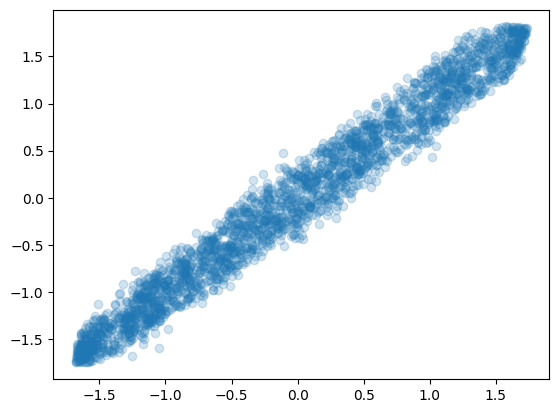

In [24]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)

<Axes: >

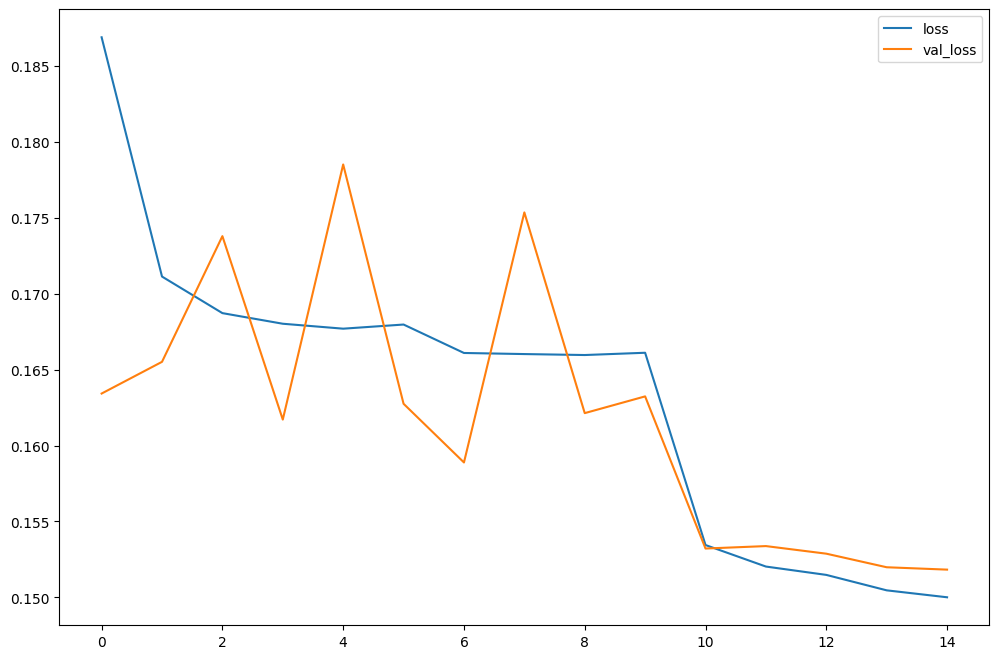

In [25]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))

# Test Score

In [26]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [27]:
# Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].values), index=Data_test.index, columns=Data_test[["Vc_1", "Wind_Speed_1", "Wind_dir_cos_1", "Wind_dir_sin_1", "Acceleration_1", "theta_1", "sigma_1", "delta_1", "roll_1", "vpath_1", "Wind_Speed_2", "Wind_dir_cos_2", "Wind_dir_sin_2", "Acceleration_2", "theta_2", "sigma_2", "delta_2", "roll_2", "vpath_2", "Vc_3", "Wind_Speed_3", "Wind_dir_cos_3", "Wind_dir_sin_3", "Acceleration_3", "theta_3", "sigma_3", "delta_3", "roll_3", "vpath_3", "Total_Weight"]].columns)
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [28]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Total_Weight"]]

In [29]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step


In [30]:
mae_current = mean_absolute_error(y_test_scaled, y_pred_scaled)
print("mae = ", mae_current*18000/170000*100)

mae =  1.6271447434144861


In [31]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [32]:
print("r2 score for weight predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for weight predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Total_Weight"], output[:,-1])))
print("MAE score for weight predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Total_Weight"]-output[:,-1])*Data_test["Total_Weight"]**-1))
print("Maximum error for weight predictions: %.5f" % np.max(np.abs(Data_test["Total_Weight"]-output[:,-1])))

r2 score for weight predictions: 0.96607
MAE score for weight predictions: 2162.79892
MAE score for weight predictions as percentage: 1.46661 %
Maximum error for weight predictions: 8719.86390


In [33]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

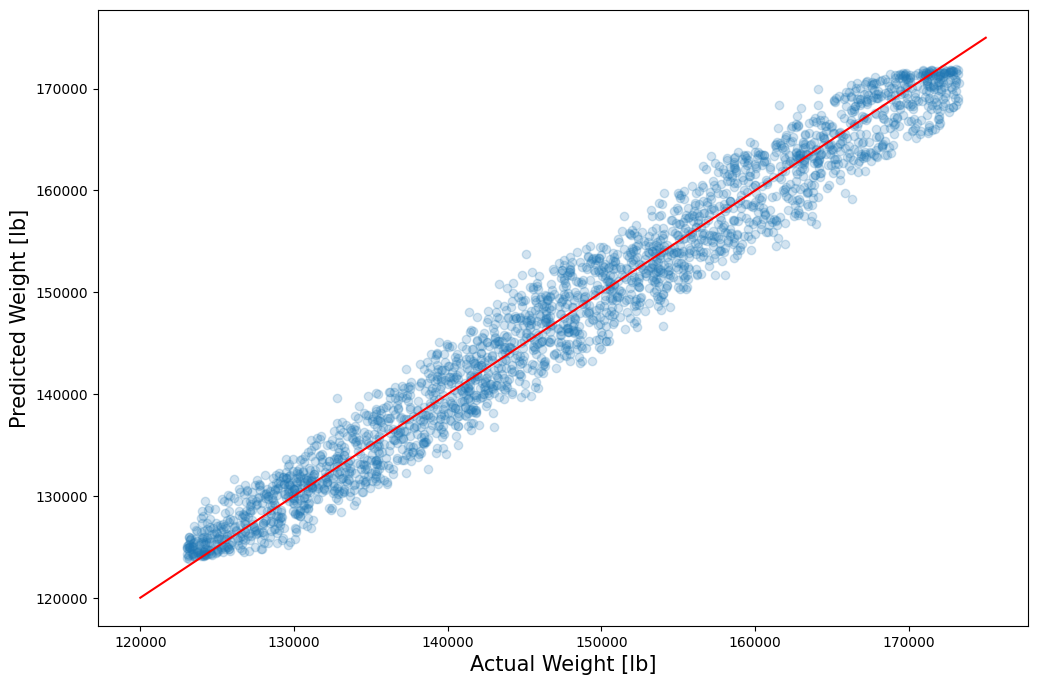

In [34]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Total_Weight"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [lb]", fontsize=15)
plt.xlabel("Actual Weight [lb]", fontsize=15)
plt.plot([120000, 175000], [120000, 175000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_scatter.png", dpi=300)
plt.show()

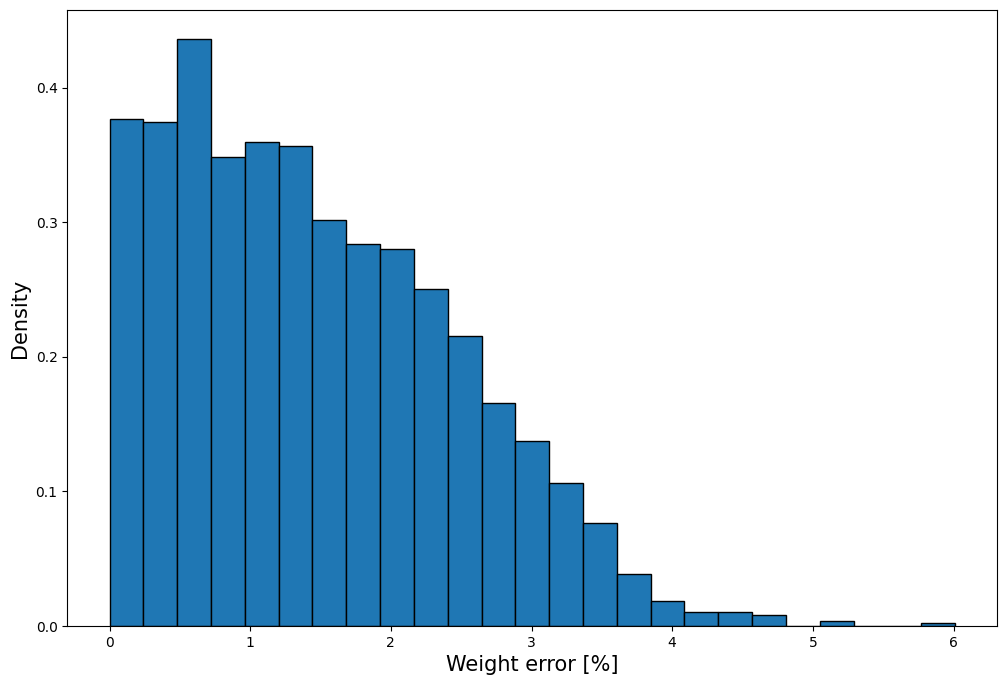

In [35]:
errors_lst = np.abs(100*(output[:,-1] - Data_test["Total_Weight"].values)/Data_test["Total_Weight"])
plt.figure(figsize=(12,8))
plt.hist(errors_lst, bins=25, ec="k", density=True)
plt.xlabel("Weight error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
# plt.xlim([-5,5])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_1.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_error_distribution.png", dpi=300)
plt.show()

# Save Model

In [36]:
model.save("Models\model_weight\model_weight.keras")
dump(scaler, "Models\model_weight\scaler_weight.bin", compress=True)

['Models\\model_weight\\scaler_weight.bin']

# Thrust Model Data Gathering

In [112]:
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]

In [187]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])

In [188]:
n = 0.9
f_lst_train = [f for f in f_lst if f not in f_lst_test]
random.shuffle(f_lst_train)  # shuffle in-place
train_end = int(n * len(f_lst_train))
train = f_lst_train[:train_end]
val = f_lst_train[train_end:]
test = f_lst_test

In [189]:
Data_Train_thrust = pd.DataFrame(columns=thrust_columns)
Data_Val_thrust = pd.DataFrame(columns=thrust_columns)
Data_Test_Thrust = pd.DataFrame(columns=thrust_columns)

In [190]:
dfs = []
for f in train[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Train_Thrust = pd.concat(dfs, ignore_index=True)
Data_Train_Thrust.to_csv("Data/Data_Train_Thrust_Dep.csv", index=False)

dfs = []
for f in val[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Val_Thrust = pd.concat(dfs, ignore_index=True)
Data_Val_Thrust.to_csv("Data/Data_Val_Thrust_Dep.csv", index=False)

dfs = []
for f in test[:]:
    df = pd.read_csv(f)
    dfs.append(df[thrust_columns])
Data_Test_Thrust = pd.concat(dfs, ignore_index=True)
Data_Test_Thrust.to_csv("Data/Data_Test_Thrust_Dep.csv", index=False)

# Read the Data for Thrust Model

In [191]:
Data_train = pd.read_csv("Data\Data_Train_Thrust_Dep.csv")
Data_val = pd.read_csv("Data\Data_Val_Thrust_Dep.csv")
Data_test = pd.read_csv("Data\Data_Test_Thrust_Dep.csv")

In [192]:
scaler = StandardScaler().fit(Data_train.values)

In [193]:
Data_train_scaled = pd.DataFrame(scaler.transform(Data_train.values), index=Data_train.index, columns=Data_train.columns)
Data_train_scaled.dropna(inplace=True)

In [194]:
Data_val_scaled = pd.DataFrame(scaler.transform(Data_val.values), index=Data_val.index, columns=Data_val.columns)
Data_val_scaled.dropna(inplace=True)

In [195]:
X_train = Data_train_scaled[thrust_columns[:-1]]
y_train = Data_train_scaled[['Thrust']]
X_val = Data_val_scaled[thrust_columns[:-1]]
y_val = Data_val_scaled[['Thrust']]

In [196]:
X_train.shape

(6324663, 12)

# Create the Thrust Model

In [197]:
model = Sequential()
model_dropout = 0.02
model_activation = 'sigmoid'
batch_size = 256

model.add(Dense(64, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(64, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(32, activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [198]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,617 (29.75 KB)

 Trainable params: 7,617 (29.75 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Thrust Model

## 1st LR

In [199]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [200]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.1525 - val_loss: 0.1019
Epoch 2/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.1146 - val_loss: 0.0988
Epoch 3/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 0.1091 - val_loss: 0.0936
Epoch 4/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.1053 - val_loss: 0.0911
Epoch 5/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.1034 - val_loss: 0.0973
Epoch 6/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.1018 - val_loss: 0.0896
Epoch 7/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - loss: 0.1007 - val_loss: 0.0893
Epoch 8/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 0.0997 - val_loss: 0.0945
Epoch 9/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0991 - val_loss: 0.0870
Epoch 10/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0986 - val_loss: 0.0866
Epoch 11/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - loss: 0.0983 - val_loss: 0.08

In [201]:
losses = pd.DataFrame(model.history.history)

## 2nd LR

In [202]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [203]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [204]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0924 - val_loss: 0.0819
Epoch 2/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0918 - val_loss: 0.0799
Epoch 3/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0917 - val_loss: 0.0807
Epoch 4/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0915 - val_loss: 0.0813


In [205]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

## 3rd LR

In [206]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [207]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [208]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0909 - val_loss: 0.0805
Epoch 2/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0908 - val_loss: 0.0807
Epoch 3/50
24706/24706 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0909 - val_loss: 0.0809


<Axes: >

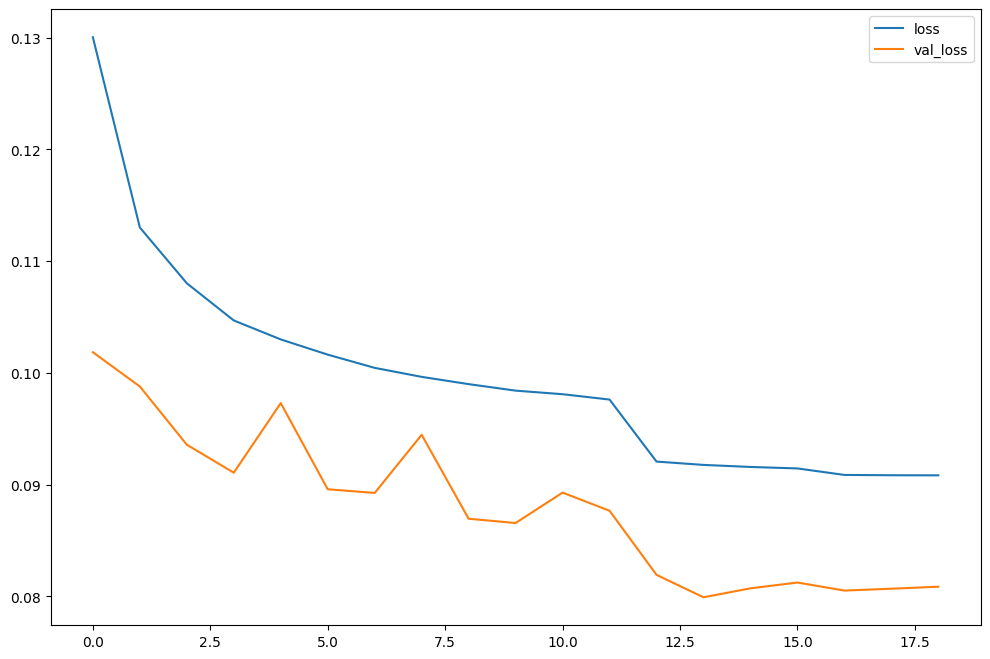

In [209]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))

# Test Score

In [210]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test.values), index=Data_test.index, columns=Data_test.columns)
Data_test_scaled.dropna(inplace=True)

In [211]:
X_test_scaled = Data_test_scaled[thrust_columns[:-1]]
y_test_scaled = Data_test_scaled[['Thrust']]

In [212]:
y_pred_scaled = model.predict(X_test_scaled)

20052/20052 ━━━━━━━━━━━━━━━━━━━━ 12s 579us/step


In [213]:
print("r2 score for thrust predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust predictions: %.5f" % (metrics.mean_absolute_error(y_test_scaled, y_pred_scaled)))
print("Maximum error for thrust predictions: %.5f" % np.max(y_pred_scaled-y_test_scaled))

r2 score for thrust predictions: 0.98368
MAE score for thrust predictions: 0.07565
Maximum error for thrust predictions: 4.08780


# Save Model

In [214]:
model.save("Models\model_thrust\model_thrust.keras")
dump(scaler, "Models\model_thrust\scaler_thrust.bin", compress=True)

['Models\\model_thrust\\scaler_thrust.bin']

# Predict Outputs for a Single Flight

In [347]:
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")

In [217]:
test_flight = pd.read_csv(test[200])

In [218]:
flight_data = test_flight[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

start_time = time.time()
y_pred_scaled = model_thrust.predict(X_flight)
# y_pred_scaled = model_thrust(X_flight)
# y_pred_tensor = y_pred_scaled['dense_9']
# y_pred_np = y_pred_tensor.numpy().reshape(-1, 1)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
# output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_np), axis=1))
#output = scaler.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]
end_time = time.time()
print(end_time - start_time)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
0.14191102981567383


In [219]:
print("r2 score for thrust predictions with exact weight: %.5f" % (metrics.r2_score(flight_data["Thrust"], y_pred)))
print("MAE score for thrust predictions with exact weight: %.5f" % (metrics.mean_absolute_error(flight_data["Thrust"], y_pred)))
print("Maximum error for thrust predictions with exact weight: %.5f" % np.max(y_pred-flight_data["Thrust"]))

r2 score for thrust predictions with exact weight: 0.98858
MAE score for thrust predictions with exact weight: 160.03895
Maximum error for thrust predictions with exact weight: 975.77348


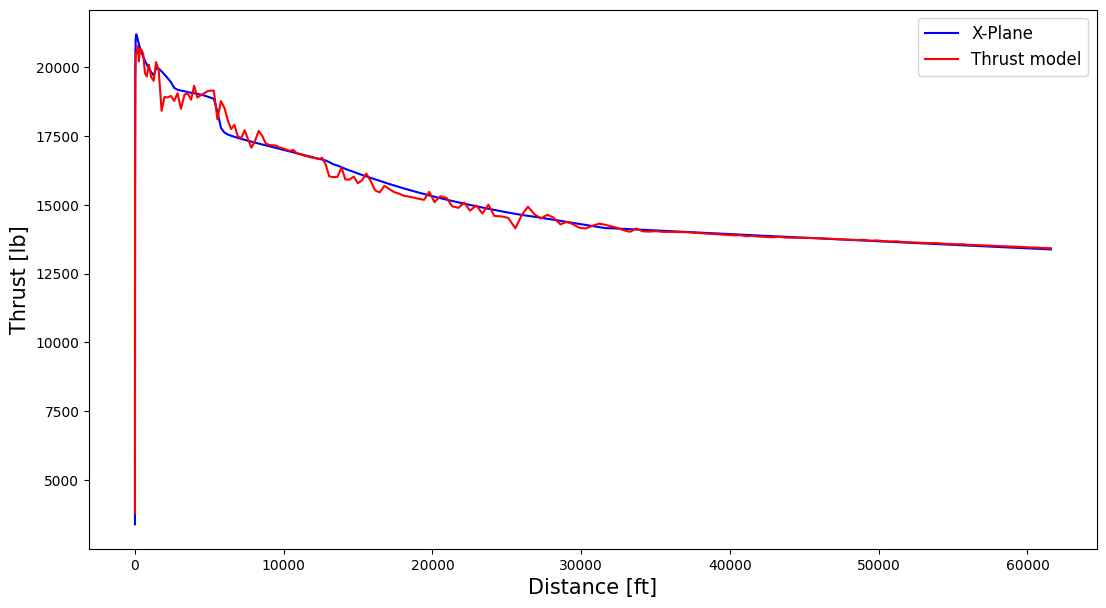

In [220]:
plt.figure(figsize=(13,7))
plt.plot(test_flight["Distance"], test_flight["Thrust"], "b")
plt.plot(test_flight["Distance"], y_pred, "r")
plt.xlabel("Distance [ft]", fontsize=15)
plt.ylabel("Thrust [lb]", fontsize=15)
plt.legend(["X-Plane", "Thrust model"], fontsize=12)
# plt.xticks(ticks=[0,20000,40000,60000,80000,100000,120000,140000], labels=["0","20,000","40,000",""])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Thrust_0.png", bbox_inches="tight", facecolor='white', transparent=False)

plt.savefig("thrust_predictions_single_flight.png", dpi=300)
plt.show()

## Normal Thrust Model Error on Max Thrust Values

In [353]:
df_results = pd.DataFrame(columns = ["R2", "MAE", "Thrust_Max_Pred", "Thrust_Max_Actual", "Thrust_Maxx_Error_Perc"])
i = 0
for f in test:
    test_flight = pd.read_csv(f)
    flight_data = test_flight[thrust_columns]
    flight_data.dropna(inplace=True)
    flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
    X_flight = flight_data_scaled[thrust_columns[:-1]]
    
    y_pred_scaled = model_thrust.predict(X_flight)
    output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
    y_pred = output[:,-1]

    df_results.loc[i, "R2"] = metrics.r2_score(flight_data["Thrust"], y_pred)
    df_results.loc[i, "MAE"] = metrics.mean_absolute_error(flight_data["Thrust"], y_pred)
    df_results.loc[i, "Thrust_Max_Pred"] = np.max(y_pred)
    df_results.loc[i, "Thrust_Max_Actual"] = np.max(flight_data["Thrust"])
    df_results.loc[i, "Thrust_Max_Error_Perc"] = 100*np.abs(df_results.loc[i, "Thrust_Max_Pred"]-df_results.loc[i, "Thrust_Max_Actual"])/df_results.loc[i, "Thrust_Max_Actual"]
    i += 1

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━

In [355]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(df_results["Thrust_Max_Actual"], df_results["Thrust_Max_Pred"])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(df_results["Thrust_Max_Error_Perc"]))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(df_results["Thrust_Max_Actual"]-df_results["Thrust_Max_Pred"])))

r2 score for thrust max predictions: 0.93947
MAE score for thrust max predictions: 401.35660
MAE score for thrust max predictions as percentage: 1.92832 %
Maximum error for thrust max predictions: 2626.56844


Text(0, 0.5, 'Density')

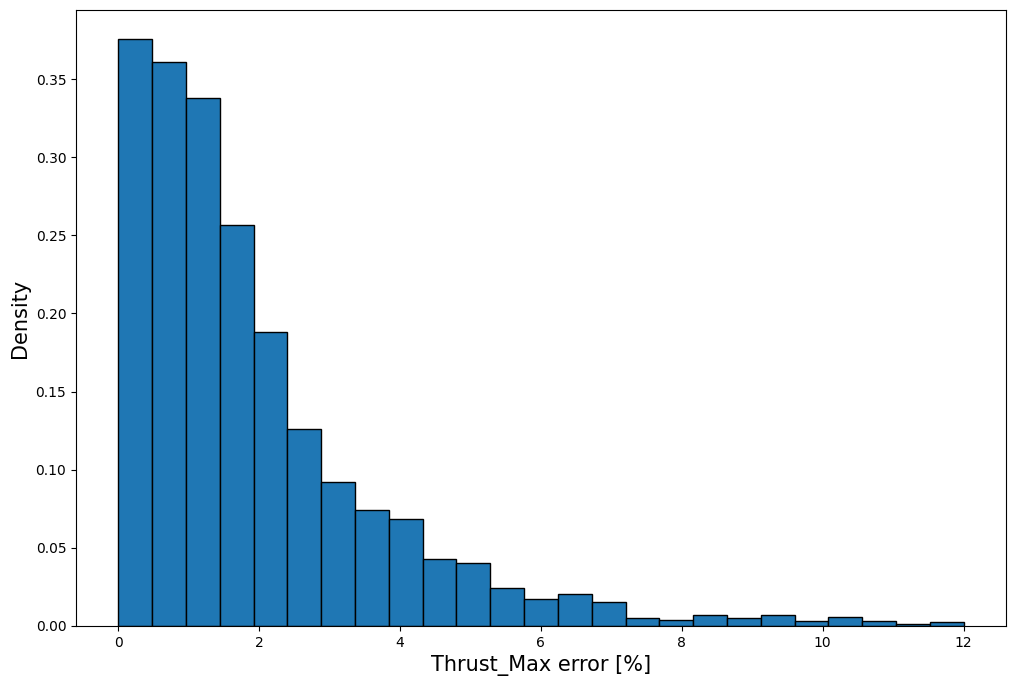

In [356]:
plt.figure(figsize=(12,8))
plt.hist(df_results["Thrust_Max_Error_Perc"], bins=25, ec="k", density=True)
plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)

# Thrust Max Model

In [166]:
Data = pd.read_csv("Data/Data_Train_Weight_Dep.csv")
n1 = 0.8
n2 = 0.9

In [167]:
# all_names = desired_columns
all_names = ["acc_max", "Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight", "Thrust_Max"]
x_names = all_names[:-1]

In [168]:
scaler = StandardScaler().fit(Data[all_names].values)
Data_scaled = pd.DataFrame(scaler.transform(Data[all_names].values), index=Data.index, columns=all_names)

In [169]:
X_train, X_val, y_train, y_val = train_test_split(Data_scaled[x_names], Data_scaled[['Thrust_Max']], test_size=(n2-n1)/n2)

## Create the Model

In [170]:
model = Sequential()
model_dropout = 0.0
model_activation = 'tanh'
batch_size = 16

model.add(Dense(16, input_dim=X_train.shape[1], activation=model_activation))
model.add(Dropout(model_dropout))
model.add(Dense(16, activation=model_activation))
model.add(Dropout(model_dropout))

model.add(Dense(1))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mae')

In [171]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

## Train the thrust max Model

### 1st LR

In [172]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=3)

In [173]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val),
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - loss: 0.2754 - val_loss: 0.2086
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - loss: 0.2076 - val_loss: 0.1966
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - loss: 0.2055 - val_loss: 0.1973
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - loss: 0.2000 - val_loss: 0.1879
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 837us/step - loss: 0.2010 - val_loss: 0.1941
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.1993 - val_loss: 0.2000
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - loss: 0.1999 - val_loss: 0.1972


In [174]:
losses = pd.DataFrame(model.history.history)

### 2nd LR

In [175]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [176]:
model.optimizer.learning_rate.assign(0.001)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

In [177]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - loss: 0.1813 - val_loss: 0.1783
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.1757 - val_loss: 0.1760
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - loss: 0.1768 - val_loss: 0.1766
Epoch 4/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 852us/step - loss: 0.1767 - val_loss: 0.1748
Epoch 5/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 0.1750 - val_loss: 0.1761
Epoch 6/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.1749 - val_loss: 0.1742
Epoch 7/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.1757 - val_loss: 0.1764
Epoch 8/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step - loss: 0.1744 - val_loss: 0.1735
Epoch 9/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - loss: 0.1763 - val_loss: 0.1733
Epoch 10/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - loss: 0.1753 - val_loss: 0.1727
Epoch 11/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - loss: 0.1717 - val_loss: 0.1773
Epoch 12

In [178]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)

### 3rd LR

In [179]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', min_delta=0.0005, patience=2)

In [180]:
model.optimizer.learning_rate.assign(0.0001)

<tf.Tensor: shape=(), dtype=float32, numpy=9.999999747378752e-05>

In [181]:
model.fit(x=X_train, y=y_train, 
          validation_data=(X_val, y_val), 
          batch_size=batch_size, epochs=50, callbacks=[callback])

Epoch 1/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - loss: 0.1717 - val_loss: 0.1723
Epoch 2/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - loss: 0.1698 - val_loss: 0.1720
Epoch 3/50
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - loss: 0.1729 - val_loss: 0.1721


In [182]:
predictions = model.predict(X_val)
mae_current = mean_absolute_error(y_val, predictions)
print("mae = ", mae_current*18000/170000*100)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step
mae =  1.8220982656759372


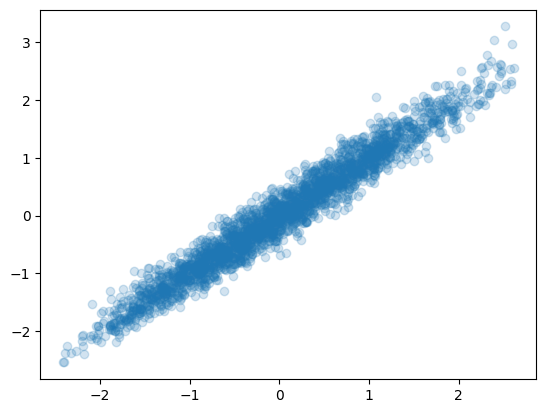

In [183]:
plt.scatter(predictions.flatten(), y_val, alpha=0.2)

<Axes: >

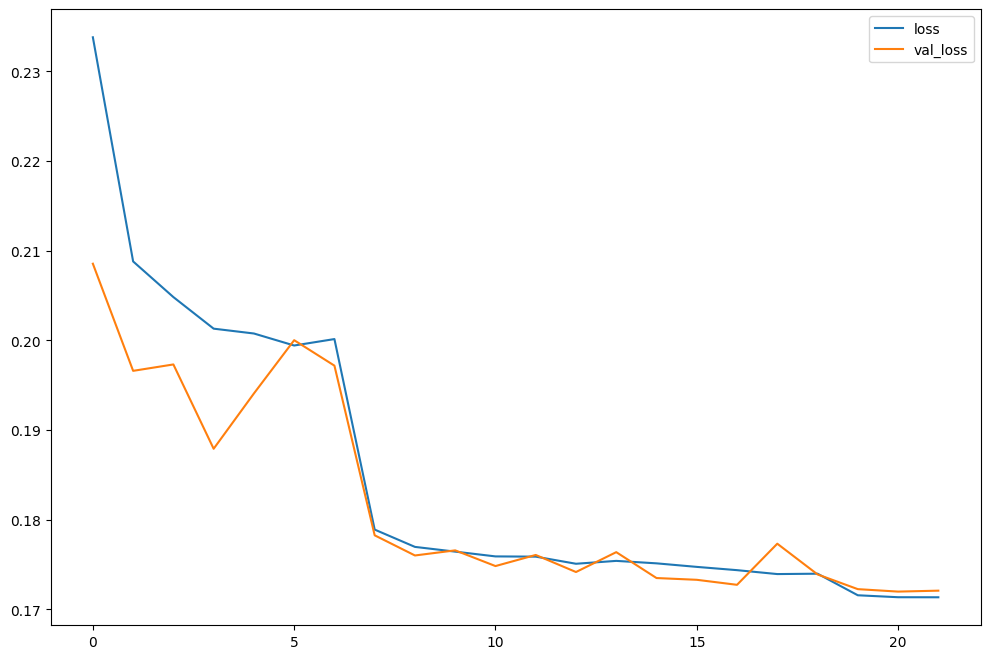

In [184]:
losses = pd.concat([losses, pd.DataFrame(model.history.history)], axis=0)
losses.reset_index(drop=True).plot(figsize=(12,8))

## Test Score

In [185]:
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")

In [186]:
Data_test_scaled = pd.DataFrame(scaler.transform(Data_test[all_names].values), index=Data_test.index, columns=all_names)

In [187]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Thrust_Max"]]

In [188]:
y_pred_scaled = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step


In [189]:
output = scaler.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [190]:
print("r2 score for thrust max predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for thrust max predictions: %.5f" % (metrics.mean_absolute_error(Data_test["Thrust_Max"], output[:,-1])))
print("MAE score for thrust max predictions as percentage: %.5f %%" % np.mean(100*np.abs(Data_test["Thrust_Max"]-output[:,-1])*Data_test["Thrust_Max"]**-1))
print("Maximum error for thrust max predictions: %.5f" % np.max(np.abs(Data_test["Thrust_Max"]-output[:,-1])))

r2 score for thrust max predictions: 0.95645
MAE score for thrust max predictions: 375.13140
MAE score for thrust max predictions as percentage: 1.78884 %
Maximum error for thrust max predictions: 1744.57835


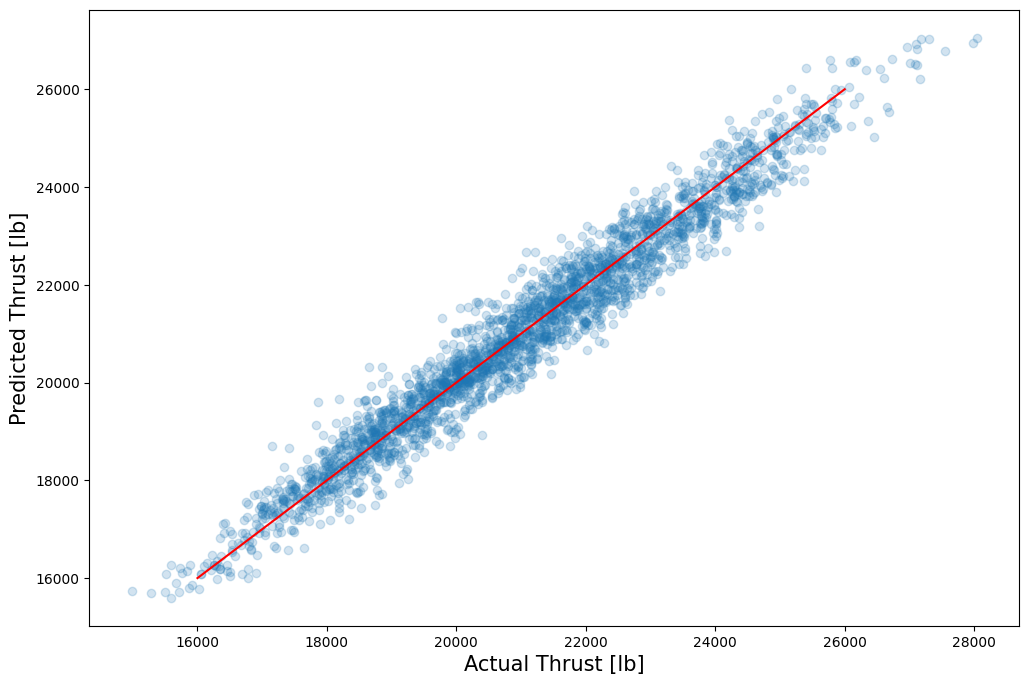

In [191]:
plt.figure(figsize=(12,8))
plt.scatter(Data_test[["Thrust_Max"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Thrust [lb]", fontsize=15)
plt.xlabel("Actual Thrust [lb]", fontsize=15)
plt.plot([16000, 26000], [16000, 26000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("thrust_max_predictions_scatter.png", dpi=300)
plt.show()

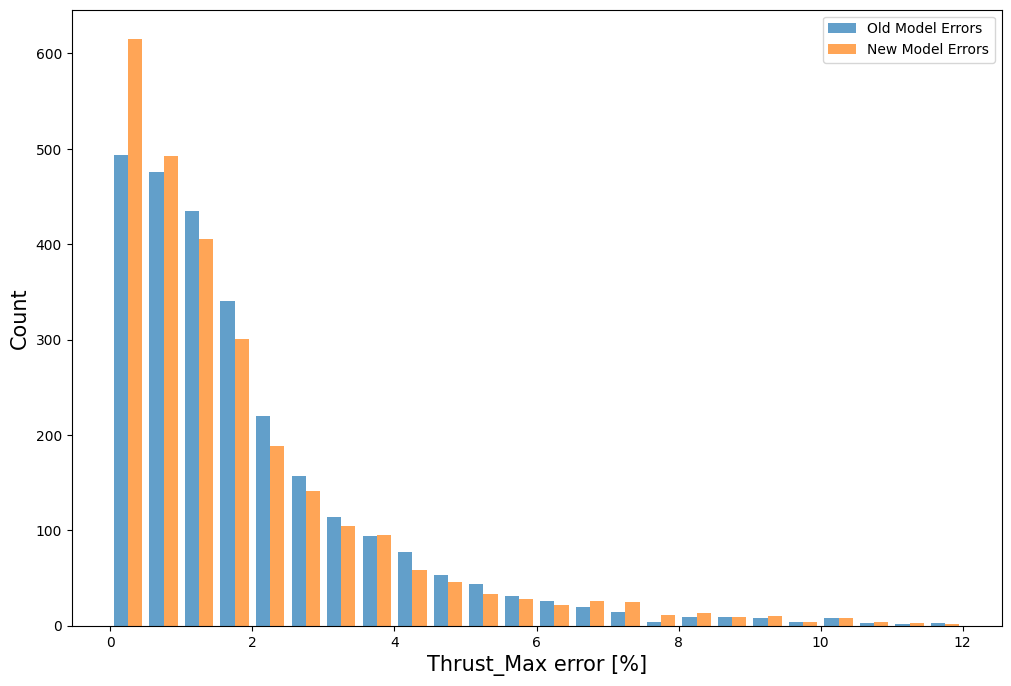

In [360]:
data1 = df_results["Thrust_Max_Error_Perc"]
data2 = errors_lst

# Compute bins
bins = np.linspace(min(data1.min(), data2.min()),
                   max(data1.max(), data2.max()), 25)

# Histogram counts
hist1, _ = np.histogram(data1, bins=bins)
hist2, _ = np.histogram(data2, bins=bins)

# Compute bin centers
bin_centers = 0.5 * (bins[1:] + bins[:-1])

width = (bins[1] - bins[0]) * 0.4

plt.figure(figsize=(12,8))
plt.bar(bin_centers - width/2, hist1, width=width, alpha=0.7, label="Old Model Errors")
plt.bar(bin_centers + width/2, hist2, width=width, alpha=0.7, label="New Model Errors")

plt.xlabel("Thrust_Max error [%]", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.legend()
plt.savefig("thrust_max_predictions_comparison.png", dpi=300)
plt.show()

### Save the Model

In [346]:
model.save("Models\model_thrust\model_thrust_max.keras")
dump(scaler, "Models\model_thrust\scaler_thrust_max.bin", compress=True)

['Models\\model_thrust\\scaler_thrust_max.bin']

# RNN Thrust Model

In [2]:
Data_dir = "Data\Departures"
f_lst = []
for f in os.listdir(Data_dir):
    if ".csv" in f:
        f_lst.append(os.path.join(Data_dir, f))
Data_test = pd.read_csv("Data/Data_Test_Weight_Dep.csv")
f_lst_test = list(Data_test["ID"])
f_lst_train = [f for f in f_lst if f not in f_lst_test]

In [3]:
# train_thrust_rnn.py
import os
import glob
import random
from typing import List, Tuple

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

# ------------------------
# Configuration / Hyperparams
# ------------------------
DATA_DIR = "Data/Departures"  # directory with flight CSVs
BATCH_SIZE = 16
NUM_EPOCHS = 30
LR = 1e-3
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
TEACHER_FORCING_PROB = 1  # during training, probability to feed true previous thrust instead of model's
MIN_JUMP = 0  # seconds
MAX_JUMP = 8  # seconds
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------
# Feature list (as described by user)
# ------------------------
POINT_FEATURES = [
    "Altitude_Above_Ground",
    "Ground_Speed",
    "Acceleration",
    "theta",
    "delta",
    "sigma",
    "vpath",
    "Roll",
    "Wind_Speed",
    "Wind_dir_cos",
    "Wind_dir_sin",
    "Total_Weight",
]
# We'll add dt and prev_thrust at runtime -> input_dim = len(POINT_FEATURES) + 2

# ------------------------
# Preprocessing per-file (Time already in seconds)
# ------------------------
def sample_sequence_from_df(df: pd.DataFrame, rng=np.random) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For a single flight df:
    - find t0 = last time where Altitude_Above_Ground == 0
    - keep rows where Altitude_Above_Ground > 0
    - starting from t0, sample times by random jumps between MIN_JUMP and MAX_JUMP seconds
    - for each sampled time, choose the first row with Time >= sample_time
    - build input vectors: POINT_FEATURES + dt + prev_thrust
      - dt for first sample = time - t0
      - prev_thrust for first sample = max thrust on ground
      - for subsequent samples prev_thrust = true Thrust of previous sampled point
    - returns: inputs (T, feat_dim), targets (T,) = true Thrust at sampled points, times array (T,)
    """
    if "Time" not in df.columns:
        raise ValueError("DataFrame must contain 'Time' column")
    if "Thrust" not in df.columns:
        raise ValueError("DataFrame must contain 'Thrust' column")

    df = df.copy()

    # find last ground time t0
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if ground_rows.shape[0] == 0:
        return None
    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # keep only airborne rows (Altitude_Above_Ground > 0) and times > t0
    air_df = df[df["Altitude_Above_Ground"] > 0].copy()
    air_df = air_df[air_df["Time"] > t0]
    if air_df.empty:
        return None

    # ensure sorted
    air_df = air_df.sort_values("Time").reset_index(drop=True)

    # sampling loop
    sampled_indices = []
    current_time = t0 + rng.randint(MIN_JUMP, MAX_JUMP)
    while True:
        # find first index in air_df with time >= current_time
        candidates = air_df[air_df["Time"] >= current_time]
        if candidates.empty:
            break
        idx = int(candidates.index[0])
        if sampled_indices and idx == sampled_indices[-1]:
            current_time += 1.0
            continue
        sampled_indices.append(idx)
        current_time += rng.randint(MIN_JUMP, MAX_JUMP)

    if len(sampled_indices) == 0:
        return None

    sampled = air_df.loc[sampled_indices].reset_index(drop=True)
    times = sampled["Time"].values.astype(float)
    targets = sampled["Thrust"].values.astype(float)

    # build inputs
    dt = np.empty(len(times), dtype=float)
    prev_thrust = np.empty(len(times), dtype=float)
    inputs = []
    for i in range(len(times)):
        if i == 0:
            dt[i] = times[0] - t0
            prev_thrust[i] = max_ground_thrust
        else:
            dt[i] = times[i] - times[i - 1]
            prev_thrust[i] = targets[i - 1]
        row_feats = sampled.loc[i, POINT_FEATURES].values.astype(float)
        inp = np.concatenate([row_feats, [dt[i], prev_thrust[i]]])
        inputs.append(inp)

    inputs = np.vstack(inputs)
    return inputs, targets.astype(float), times.astype(float)


# ------------------------
# Dataset and Collate
# ------------------------
class FlightSequenceDataset(Dataset):
    def __init__(self, file_list: List[str], rng_seed=SEED):
        self.files = file_list
        self.rng = np.random.RandomState(rng_seed)
        # We'll store processed sequences in memory to keep DataLoader simple
        self.sequences = []  # list of tuples (inputs ndarray (T, D), targets ndarray (T,), times ndarray (T,))
        for f in tqdm(self.files, desc="Preparing sequences"):
            try:
                df = pd.read_csv(f)
                df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
            except Exception as e:
                print(f"Skipping {f}: cannot read ({e})")
                continue
            result = sample_sequence_from_df(df, rng=self.rng)
            if result is None:
                continue
            inputs, targets, times = result
            # skip tiny sequences
            if inputs.shape[0] < 3:
                continue
            self.sequences.append((inputs, targets, times))

        if len(self.sequences) == 0:
            raise RuntimeError("No sequences extracted. Check your data files and preprocessing assumptions.")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        inputs, targets, times = self.sequences[idx]
        return {
            "inputs": torch.tensor(inputs, dtype=torch.float32),
            "targets": torch.tensor(targets, dtype=torch.float32),
            "length": inputs.shape[0],
            "times": torch.tensor(times, dtype=torch.float32),
        }

def collate_fn(batch):
    """
    Pads inputs and targets to the max sequence length in the batch.
    Returns:
      inputs_padded: (batch, maxT, D)
      targets_padded: (batch, maxT)
      lengths: list of lengths
      mask: (batch, maxT) 1 where valid
    """
    inputs = [item["inputs"] for item in batch]
    targets = [item["targets"] for item in batch]
    lengths = [int(item["length"]) for item in batch]

    # pad inputs (pad_sequence pads along dim=0 to max length)
    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0.0)  # (B, maxT, D)
    targets_padded = pad_sequence([t.unsqueeze(1) for t in targets], batch_first=True, padding_value=0.0).squeeze(-1)
    # mask
    maxT = inputs_padded.size(1)
    mask = torch.zeros((len(batch), maxT), dtype=torch.bool)
    for i, L in enumerate(lengths):
        mask[i, :L] = True

    return {
        "inputs": inputs_padded,
        "targets": targets_padded,
        "lengths": torch.tensor(lengths, dtype=torch.long),
        "mask": mask,
    }

# ------------------------
# Scaler utilities (fit on training sequences)
# ------------------------
def fit_scalers(dataset: FlightSequenceDataset):
    # concat all inputs to fit a StandardScaler for features except prev_thrust maybe should be scaled too
    all_inputs = np.vstack([seq[0] for seq in dataset.sequences])  # (N_total, D)
    scaler = StandardScaler()
    scaler.fit(all_inputs)  # scale everything including prev_thrust and dt
    return scaler

def apply_scaler_to_sequence_array(inputs: np.ndarray, scaler: StandardScaler):
    """
    inputs shape (T, D)
    returns scaled inputs of same shape
    """
    return scaler.transform(inputs)

# ------------------------
# Model
# ------------------------
class ThrustRNN(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int = 128, n_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_size,
                            num_layers=n_layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x_packed):
        # x_packed: PackedSequence (from pack_padded_sequence)
        packed_out, _ = self.lstm(x_packed)
        out, lengths = pad_packed_sequence(packed_out, batch_first=True)  # (B, maxT, hidden)
        # apply head time-distributed
        B, T, H = out.shape
        out_flat = out.contiguous().view(B * T, H)
        preds_flat = self.head(out_flat).view(B, T)
        return preds_flat  # (B, T)

# ------------------------
# Training loop helpers
# ------------------------
def masked_mse(preds, targets, mask):
    # preds, targets: (B, T), mask: bool (B, T)
    diff = (preds - targets) * mask.to(preds.dtype)
    mse = (diff ** 2).sum() / (mask.sum().to(preds.dtype) + 1e-8)
    return mse

def train_epoch(model, dataloader, optimizer, scaler, teacher_prob=0.9):
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="training batch progress"):
        inputs = batch["inputs"].to(DEVICE)  # (B, T, D)
        targets = batch["targets"].to(DEVICE)  # (B, T)
        lengths = batch["lengths"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)

        B, T, D = inputs.shape

        # scale inputs per-feature using scaler
        # scaler expects numpy, so we transform batchwise
        # convert to numpy -> apply scaler -> back to torch
        inp_np = inputs.cpu().numpy().reshape(-1, D)
        inp_np_scaled = scaler.transform(inp_np)
        inputs_scaled = torch.tensor(inp_np_scaled.reshape(B, T, D), dtype=torch.float32, device=DEVICE)

        # Pack sequence
        packed = pack_padded_sequence(inputs_scaled, lengths.cpu(), batch_first=True, enforce_sorted=False)

        optimizer.zero_grad()

        # Forward through LSTM head to get model predictions
        preds = model(packed)  # (B, T)

        # Training uses teacher forcing in inputs (prev_thrust inside inputs were prepared using true previous thrust)
        # But if you want to sometimes use model predictions as prev_thrust, you would need to implement a step-wise loop
        # and re-feed predicted prev_thrust into the inputs. For simplicity and stability we use teacher forcing here,
        # controlled at dataset build time via the prev_thrust values. However we'll implement a small scheduled sampling:
        # if teacher_prob < 1, perform a roll-forward correction: replace inputs' prev_thrust with model preds
        if teacher_prob < 1.0:
            # Reconstruct prev_thrust channel index (it's last channel)
            prev_idx = D - 1
            inputs_tf = inputs_scaled.clone()
            for b in range(B):
                L = lengths[b].item()
                for t in range(1, L):
                    if random.random() > teacher_prob:
                        # replace inputs_tf[b, t, prev_idx] with preds[b, t-1]
                        inputs_tf[b, t, prev_idx] = preds[b, t - 1].detach()
            # re-pack and reforward
            packed2 = pack_padded_sequence(inputs_tf, lengths.cpu(), batch_first=True, enforce_sorted=False)
            preds = model(packed2)

        loss = masked_mse(preds, targets, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item() * B

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

def save_datasets(train_ds, val_ds, path="Data/thrust_rnn_datasets.pt"):
    torch.save({
        "train_sequences": train_ds.sequences,
        "val_sequences": val_ds.sequences,
    }, path)
    print(f"Saved datasets to {path}")

def load_datasets(path="Data/thrust_rnn_datasets.pt"):
    data = torch.load(path, map_location="cpu", weights_only=False)

    # Rebuild datasets without re-processing files
    train_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    train_ds.files = []
    train_ds.rng = np.random.RandomState(42)
    train_ds.sequences = data["train_sequences"]

    val_ds = FlightSequenceDataset.__new__(FlightSequenceDataset)
    val_ds.files = []
    val_ds.rng = np.random.RandomState(43)
    val_ds.sequences = data["val_sequences"]

    return train_ds, val_ds

def eval_epoch(model, dataloader, scaler):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="eval batch progress"):
            inputs = batch["inputs"].to(DEVICE)
            targets = batch["targets"].to(DEVICE)
            lengths = batch["lengths"].to(DEVICE)
            mask = batch["mask"].to(DEVICE)

            B, T, D = inputs.shape
            inp_np = inputs.cpu().numpy().reshape(-1, D)
            inp_np_scaled = scaler.transform(inp_np)
            inputs_scaled = torch.tensor(inp_np_scaled.reshape(B, T, D), dtype=torch.float32, device=DEVICE)

            packed = pack_padded_sequence(inputs_scaled, lengths.cpu(), batch_first=True, enforce_sorted=False)
            preds = model(packed)
            loss = masked_mse(preds, targets, mask)
            total_loss += loss.item() * B
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

# Create Dataset

In [21]:
# ------------------------
# Putting it together: main()
# ------------------------
# 1) collect files
# file_list = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
file_list = copy.copy(f_lst_train)
if len(file_list) == 0:
    raise RuntimeError(f"No CSV files in {DATA_DIR}")

# split train/val
random.shuffle(file_list)
n_train = int(0.8 * len(file_list))
train_files = file_list[:n_train]
val_files = file_list[n_train:]

# 2) build datasets
train_ds = FlightSequenceDataset(train_files, rng_seed=SEED)
val_ds = FlightSequenceDataset(val_files, rng_seed=SEED + 1)
save_datasets(train_ds, val_ds)

# 3) fit scaler on train set
scaler = fit_scalers(train_ds)
dump(scaler, "Models/model_thrust/scaler_thrust_rnn.bin", compress=True)

Preparing sequences: 100%|█████████████████████████████████████████████████████████| 6132/6132 [04:38<00:00, 22.03it/s]


Saved datasets to Data/thrust_rnn_datasets.pt


['Models\\model_thrust\\scaler_thrust_rnn.bin']

# Train the Model

In [27]:
train_ds, val_ds = load_datasets()

# store input dim
sample_item = train_ds[0]["inputs"]
input_dim = sample_item.shape[1]

# 4) dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 5) model
model = ThrustRNN(input_dim=input_dim, hidden_size=HIDDEN_SIZE, n_layers=NUM_LAYERS, dropout=DROPOUT)
model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

# 6) training loop
best_val = float("inf")
for epoch in range(1, NUM_EPOCHS + 1):
    # optionally decay teacher forcing probability
    teacher_prob = max(0.5, TEACHER_FORCING_PROB - 0.02 * epoch)

    train_loss = train_epoch(model, train_loader, optimizer, scaler, teacher_prob=teacher_prob)
    val_loss = eval_epoch(model, val_loader, scaler)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | teacher_prob={teacher_prob:.3f}")

    # save best
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "scaler_mean": scaler.mean_,
            "scaler_scale": scaler.scale_,
            "input_dim": input_dim,
        }, "Models/model_thrust/best_thrust_rnn.pt")
        print("  -> saved best model")

print("Training finished. Best val loss:", best_val)

eval batch progress: 100%|███████████████████████████████████████████████████████████| 384/384 [00:05<00:00, 64.46it/s]


Epoch 01 | train_loss=155259188.205162 | val_loss=52428506.283105 | teacher_prob=0.980
  -> saved best model


eval batch progress: 100%|███████████████████████████████████████████████████████████| 384/384 [00:05<00:00, 64.67it/s]


Epoch 02 | train_loss=8982493.284774 | val_loss=115003.814528 | teacher_prob=0.960
  -> saved best model


eval batch progress: 100%|███████████████████████████████████████████████████████████| 384/384 [00:05<00:00, 65.35it/s]


...

Epoch 21 | train_loss=25315.273507 | val_loss=18931.170536 | teacher_prob=0.580


eval batch progress: 100%|███████████████████████████████████████████████████████████| 384/384 [00:06<00:00, 63.47it/s]


Epoch 22 | train_loss=27841.959051 | val_loss=18651.448513 | teacher_prob=0.560
  -> saved best model


training batch progress:   4%|██▏                                                    | 62/1533 [00:06<02:39,  9.20it/s]


KeyboardInterrupt: 

# Load Model

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


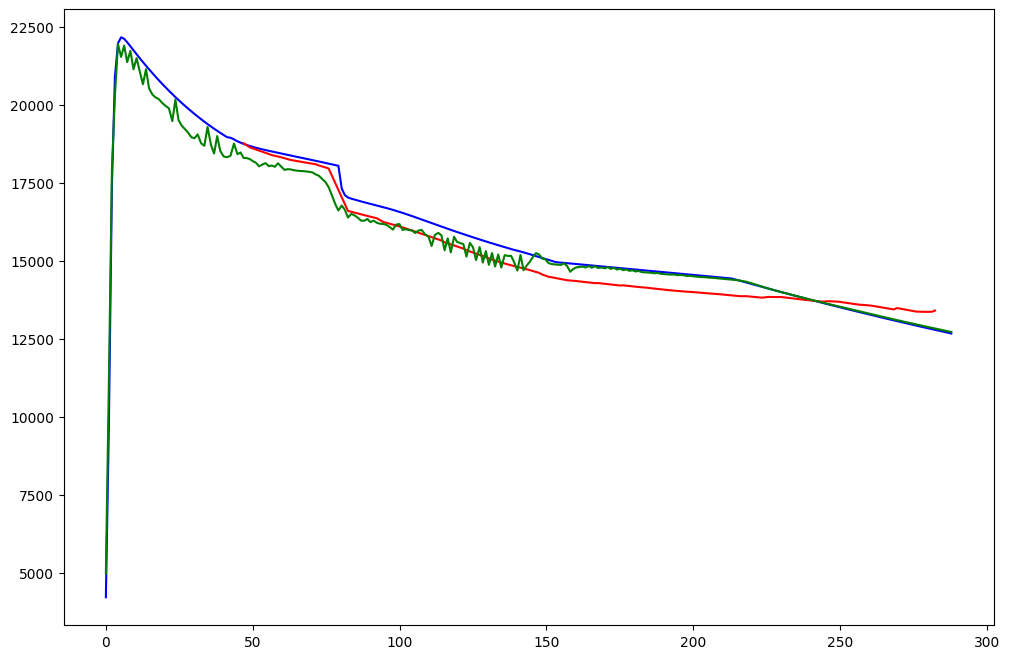

In [10]:
DEVICE = torch.device("cpu")


# ----------------------------------------------------
# Load model checkpoint + rebuild scaler
# ----------------------------------------------------
def load_thrust_model(path="Models/model_thrust/best_thrust_rnn.pt"):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    input_dim = ckpt["input_dim"]

    # rebuild model
    model = ThrustRNN(input_dim=input_dim)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    model.to(DEVICE)

    # rebuild scaler
    scaler = StandardScaler()
    scaler.mean_ = ckpt["scaler_mean"]
    scaler.scale_ = ckpt["scaler_scale"]
    scaler.n_features_in_ = scaler.mean_.shape[0]

    return model, scaler, input_dim


# ----------------------------------------------------
# Autoregressive prediction on a single sequence
# (model does NOT know ground truth thrust)
# ----------------------------------------------------
def autoregressive_predict(model, scaler, inputs):
    """
    inputs: numpy array (T, D) *unscaled* (contains dt + prev_thrust from the true data)
    We ignore the provided prev_thrust and overwrite it autoregressively.
    """

    T, D = inputs.shape

    # scale once before feeding
    x = scaler.transform(inputs.copy())
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1, T, D)

    # We'll manually overwrite prev_thrust (last feature)
    prev_idx = D - 1

    # Hidden state for autoregressive LSTM
    h, c = None, None

    preds = []

    for t in range(T):
        # feed only the prefix [0:t]
        xt = x[:, t:t+1, :]  # (1, 1, D)

        # pack single timestep
        packed = pack_padded_sequence(xt, lengths=[1], batch_first=True, enforce_sorted=False)

        out, (h, c) = model.lstm(packed, (h, c)) if h is not None else model.lstm(packed)

        out, _ = pad_packed_sequence(out, batch_first=True)  # (1, 1, H)
        pred = model.head(out).squeeze().item()
        preds.append(pred)

        # set next prev_thrust
        if t + 1 < T:
            x[:, t+1, prev_idx] = (pred - scaler.mean_[prev_idx]) / scaler.scale_[prev_idx]

    return np.array(preds)


# ----------------------------------------------------
# Predict thrust for a flight file
# ----------------------------------------------------
def run_on_flight(filepath, model, scaler):
    df = pd.read_csv(filepath)
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])

    seq = sample_sequence_from_df(df)
    if seq is None:
        print("Flight has no valid airborne data.")
        return None

    inputs, true_thrust, times = seq

    preds = autoregressive_predict(model, scaler, inputs)

    return {
        "times": times,
        "true_thrust": true_thrust,
        "pred_thrust": preds,
        "inputs": inputs,
    }


# Example usage
model, scaler, input_dim = load_thrust_model()

flight_file = f_lst_test[0]
df = pd.read_csv(flight_file)
out = run_on_flight(flight_file, model, scaler)

# Old Model
thrust_columns = ["Altitude_Above_Ground", "Ground_Speed", "Acceleration", "theta", "delta", "sigma", "vpath", "Roll", "Wind_Speed", "Wind_dir_cos", "Wind_dir_sin", "Total_Weight", "Thrust"]
model_thrust = keras.models.load_model(r"Models\model_thrust\model_thrust.keras")
scaler_thrust = load(r"Models\model_thrust\scaler_thrust.bin")
flight_data = df[thrust_columns]
flight_data_scaled = pd.DataFrame(scaler_thrust.transform(flight_data.values), index=flight_data.index, columns=flight_data.columns)
X_flight = flight_data_scaled[thrust_columns[:-1]]

y_pred_scaled = model_thrust.predict(X_flight)
output = scaler_thrust.inverse_transform(np.concatenate((X_flight.values, y_pred_scaled.reshape(len(y_pred_scaled),1)), axis=1))
y_pred = output[:,-1]

plt.figure(figsize=(12,8))
plt.plot(df["Time"], df["Thrust"], "b")
plt.plot(out["times"], out["pred_thrust"], "r")
plt.plot(df['Time'], y_pred, "g")


## Test on a Single Flight

In [7]:
def predict_thrust_from_df(df, model, scaler, device="cpu"):
    """
    df: full flight dataframe
    model: loaded ThrustRNN model
    scaler: StandardScaler reconstructed from saved mean_ and scale_
    Returns:
        times: np.array of timestamps (airborne)
        preds: np.array of predicted thrust values
    """
    POINT_FEATURES = [
    "Altitude_Above_Ground",
    "Ground_Speed",
    "Acceleration",
    "theta",
    "delta",
    "sigma",
    "vpath",
    "Roll",
    "Wind_Speed",
    "Wind_dir_cos",
    "Wind_dir_sin",
    "Total_Weight",
    ]
    # ---- 1) PREPARE DATAFRAME ----
    df = df.dropna(subset=POINT_FEATURES + ["Time", "Thrust"])
    df = df.sort_values("Time").reset_index(drop=True)

    # ---- 2) Find last ground point (= t0) ----
    ground_rows = df[df["Altitude_Above_Ground"] == 0]
    if len(ground_rows) == 0:
        raise ValueError("No ground rows in the dataframe!")

    t0 = float(ground_rows.iloc[-1]["Time"])
    max_ground_thrust = float(ground_rows["Thrust"].max())

    # ---- 3) Extract airborne rows ----
    air_df = df[(df["Altitude_Above_Ground"] > 0) & (df["Time"] > t0)].reset_index(drop=True)
    if air_df.empty:
        raise ValueError("No airborne rows found after t0.")

    times = air_df["Time"].values.astype(float)
    num_steps = len(times)

    # ---- 4) Build inputs step-by-step (autoregressive) ----
    input_dim = len(POINT_FEATURES) + 2   # dt + prev_thrust
    preds = np.zeros(num_steps, dtype=float)

    prev_thrust = max_ground_thrust

    for i in range(num_steps):
        feats = air_df.loc[i, POINT_FEATURES].values.astype(float)

        # dt computation
        if i == 0:
            dt = times[0] - t0
        else:
            dt = times[i] - times[i - 1]

        inp_vec = np.concatenate([feats, [dt, prev_thrust]])  # shape (input_dim,)
        inp_scaled = scaler.transform(inp_vec.reshape(1, -1))  # scale features

        # ---- 5) Model expects (batch=1, T=1, D) packed ----
        x = torch.tensor(inp_scaled, dtype=torch.float32).reshape(1, 1, -1).to(device)
        packed = pack_padded_sequence(x, lengths=[1], batch_first=True, enforce_sorted=False)

        with torch.no_grad():
            thrust_pred = model(packed)[0, 0].item()

        preds[i] = thrust_pred
        prev_thrust = thrust_pred  # autoregressive feedback

    return times, preds


In [12]:
f_lst_test[1]

'Data\\Departures\\2024-07-23---15-35-30.csv'

In [13]:
df = pd.read_csv(f_lst_test[1])

times, pred_thrust = predict_thrust_from_df(df, model_thrust_rnn, scaler_thrust_rnn, device=DEVICE)

print(times)
print(pred_thrust)

[ 25.9375  27.      28.125   29.3125  30.375   31.5625  32.625   33.75
  34.875   36.      37.1875  38.25    39.3125  40.4375  41.625   42.8125
  44.      45.125   46.3125  47.5     48.5625  49.625   50.6875  51.8125
  52.875   54.      55.1875  56.25    57.3125  58.5     59.5625  60.6875
  61.75    62.875   64.0625  65.1875  66.375   67.4375  68.5     69.625
  70.75    71.8125  73.0625  74.1875  75.25    76.3125  77.375   78.5
  79.5625  80.6875  81.8125  82.9375  84.125   85.1875  86.375   87.5
  88.5625  89.625   90.75    91.9375  93.125   94.1875  95.4375  96.5
  97.5625  98.625   99.6875 100.875  101.9375 103.125  104.1875 105.25
 106.375  107.625  108.8125 109.875  111.0625 112.3125 113.375  114.5
 115.75   116.9375 118.     119.0625 120.1875 121.25   122.375  123.625
 124.75   125.8125 126.9375 128.     129.0625 130.25   131.375  132.5
 133.6875 134.875  135.9375 137.0625 138.25   139.375  140.4375 141.5625
 142.75   143.8125 144.9375 146.125  147.1875 148.25   149.3125 150.4375

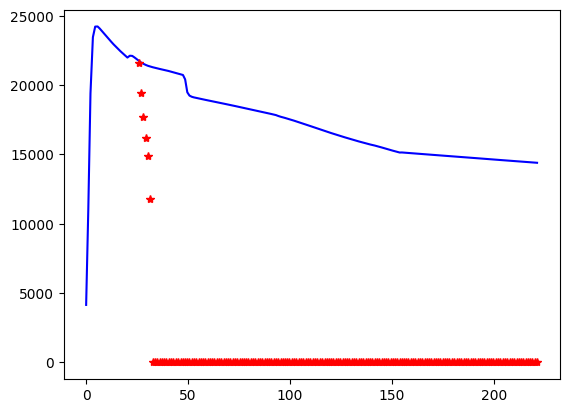

In [15]:
plt.plot(df["Time"],df["Thrust"], "b")
plt.plot(times, pred_thrust, "*r")